# Density-Only ShellForce Corr Model on Lattice ABP

This notebook applies the short-time shell-force CNEEP model used for Corr SAOU to lattice ABP trajectories.  The ABP CTMC is simulated with exact Gillespie events.  The model receives only the scalar occupancy/density field; particle orientations and any visualization colors are hidden from the network.

In [23]:
import os
import sys

candidate_roots = [
    os.environ.get("CNEEP_V2_ROOT"),
    os.path.abspath(".."),
    os.path.abspath("."),
    "/home/ldh041203/projects/CNEEP_v2",
]

CNEEP_V2_ROOT = None
for candidate in candidate_roots:
    if candidate and os.path.exists(os.path.join(candidate, "data", "lattice_abp", "core.py")):
        CNEEP_V2_ROOT = candidate
        break

if CNEEP_V2_ROOT is None:
    raise RuntimeError("Could not locate CNEEP_v2 root. Set CNEEP_V2_ROOT.")

if CNEEP_V2_ROOT not in sys.path:
    sys.path.append(CNEEP_V2_ROOT)

print("CNEEP_v2 root:", CNEEP_V2_ROOT)

CNEEP_v2 root: /home/ldh041203/projects/CNEEP_v2


In [24]:
from argparse import Namespace
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

from data.lattice_abp.core import LatticeABP
from utils.sampler import CartesianSeqSampler

## 1. Hyperparameters

In [25]:
opt = Namespace()
opt.model_type = "MultiScaleShellForceCNEEP2D_Tanh"
opt.device = "cuda" if torch.cuda.is_available() else "cpu"

# alpha-NEEP objective
opt.alpha = -0.5
opt.beta = 0.0
opt.lam = 0.0
opt.threshold = 0.01

# model / data shape
opt.periodic = True
opt.positional = False
opt.n_components = 1
opt.input_shape = (64, 64)
opt.seq_len = 2

# ShellForce branch settings
opt.max_distance = 3
opt.include_k0 = False
opt.shell_center_mode = "relative_only"
opt.shell_force_bias = False
opt.shell_relative_mode = "learned_absolute"
opt.shell_weight_normalization = "none"
opt.shell_force_activation = "elu"

# training
opt.n_iter = 2000
opt.train_batch_size = 4096
opt.test_batch_size = 1024
opt.video_batch_size = 512
opt.lr = 1e-4
opt.wd = 1e-5
opt.input_scalar = 1
opt.loss_scalar = 1
opt.scalar = 1
opt.clip_norm = 1
opt.record_freq = 100
opt.seed = 3
opt.n_layer = 2
opt.n_channel = 32
opt.n_hidden = 2
opt.val_ratio = 0.2

# Lattice ABP parameters: high persistence, moderately dense MIPS-prone regime.
abp_params = dict(
    L=64,
    v_plus=10.0,
    v_zero=1,
    v_minus=1,
    D_rot=0.1,
    density=0.55,
    bc_mode="periodic",
    device=opt.device,
    seed=123,
)

# Exact Gillespie simulation controls.
n_trajs = 32
burn_in_events = 1000_000
n_snapshots = 10000
steps_per_snapshot = 1
n_steps = n_snapshots * steps_per_snapshot
save_interval = steps_per_snapshot

n_trajs_test = 1
n_snapshots_test = 1000
n_steps_test = n_snapshots_test * steps_per_snapshot
test_seed = 456

torch.manual_seed(opt.seed)
np.random.seed(opt.seed)

result_folder = os.path.join(CNEEP_V2_ROOT, "results")
current_result_folder = os.path.join(
    result_folder, f"CorrLABP-ShellForce-{datetime.now().strftime('%Y-%m-%d-%H%M%S')}"
)
os.makedirs(current_result_folder, exist_ok=True)
current_checkpoint_path = os.path.join(current_result_folder, "model_parameter.pth.tar")
best_checkpoint_path = os.path.join(current_result_folder, "best_model_parameter.pth.tar")

print(f"Device: {opt.device}")
print(f"Results: {current_result_folder}")
print(f"ABP Pe: {(abp_params['v_plus'] - abp_params['v_minus']) / (2 * abp_params['D_rot']):.2f}")
print(f"Density-only input: n_components={opt.n_components}")
print(f"Burn-in events per ensemble: {burn_in_events:,}")
print(f"Recorded snapshots: {n_snapshots}, steps/snapshot: {steps_per_snapshot}")

Device: cuda
Results: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-ShellForce-2026-07-02-140900
ABP Pe: 45.00
Density-only input: n_components=1
Burn-in events per ensemble: 1,000,000
Recorded snapshots: 10000, steps/snapshot: 1


## 2. Exact Gillespie Trajectories

In [26]:
def encode_density_result(result):
    """Convert occupancy snapshots to (M, T, L, L) density-only tensors."""
    O = result["O_traj"].float()  # (T, B, L, L)
    return O.permute(1, 0, 2, 3).contiguous()


print(f"[INFO] Generating TRAIN trajectories with exact Gillespie events (B={n_trajs})")
sim_train = LatticeABP(**abp_params)
result_train = sim_train.simulate(
    B=n_trajs,
    n_steps=n_steps,
    burn_in=burn_in_events,
    method="gillespie",
    save_interval=save_interval,
    show_progress=True,
)
train_states = encode_density_result(result_train)
print("Train density states:", train_states.shape)

print(f"[INFO] Generating TEST trajectory with exact Gillespie events (B={n_trajs_test})")
sim_test = LatticeABP(**{**abp_params, "seed": test_seed})
result_test = sim_test.simulate(
    B=n_trajs_test,
    n_steps=n_steps_test,
    burn_in=burn_in_events,
    method="gillespie",
    save_interval=save_interval,
    show_progress=True,
)
test_states = encode_density_result(result_test)
print("Test density states:", test_states.shape)

[INFO] Generating TRAIN trajectories with exact Gillespie events (B=32)


Train density states: torch.Size([32, 10000, 64, 64])
[INFO] Generating TEST trajectory with exact Gillespie events (B=1)


Test density states: torch.Size([1, 1000, 64, 64])


## 3. Prepare Video Tensors

In [27]:
opt.M = train_states.shape[0]
opt.L = train_states.shape[1]
opt.M_test = test_states.shape[0]
opt.L_test = test_states.shape[1]
opt.input_shape = (abp_params["L"], abp_params["L"])

train_val_split_idx = int(opt.M * (1 - opt.val_ratio))
M_train_new = train_val_split_idx
M_val = opt.M - M_train_new

train_video = train_states[:M_train_new].float().to(opt.device)
val_video = train_states[M_train_new:].float().to(opt.device)
test_video = test_states.float().to(opt.device)

mean = torch.mean(train_video, dim=(0, 1, 2, 3), keepdim=True)
std = torch.std(train_video, dim=(0, 1, 2, 3), keepdim=True).clamp_min(1e-6)
transform = lambda x: (x - mean.to(x.device)) * opt.input_scalar / std.to(x.device)

print("Train video:", train_video.shape)
print("Val video:  ", val_video.shape)
print("Test video: ", test_video.shape)
print("Density mean:", float(mean.detach().cpu()))
print("Density std: ", float(std.detach().cpu()))

Train video: torch.Size([25, 10000, 64, 64])
Val video:   torch.Size([7, 10000, 64, 64])
Test video:  torch.Size([1, 1000, 64, 64])
Density mean: 0.5498046875
Density std:  0.4975133240222931


## 4. Train ShellForce Model

Model params: 5,824


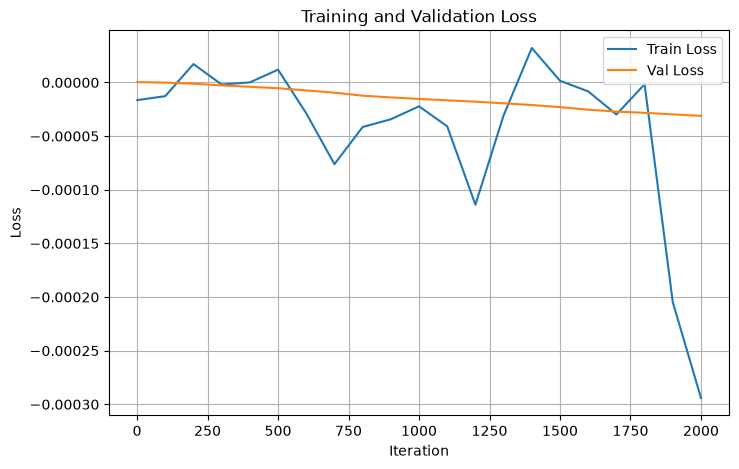

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [08:23<00:00,  3.97it/s]

Training finished.
Best checkpoint: /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-ShellForce-2026-07-02-140900/best_model_parameter.pth.tar


In [28]:
from models.NEEP_ShellForce_2D import MultiScaleShellForceCNEEP2D, MultiScaleShellForceCNEEP2D_Tanh

if opt.model_type == "MultiScaleShellForceCNEEP2D_Tanh":
    model = MultiScaleShellForceCNEEP2D(opt).to(opt.device)
elif opt.model_type == "MultiScaleShellForceCNEEP2D":
    model = MultiScaleShellForceCNEEP2D(opt).to(opt.device)
else:
    raise ValueError(f"Unknown model_type: {opt.model_type}")

optim = torch.optim.AdamW(model.parameters(), opt.lr, weight_decay=opt.wd)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

train_sampler = CartesianSeqSampler(
    M_train_new, opt.L, opt.seq_len, opt.train_batch_size, device=opt.device
)
val_sampler = CartesianSeqSampler(
    M_val, opt.L, opt.seq_len, opt.test_batch_size, device=opt.device, train=False
)

best_val_loss = float("inf")
smoothing = 0.5
smooth_train_loss = None
smooth_val_loss = None
history_train_loss = []
history_val_loss = []
history_iters = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))
line_train, = ax.plot([], [], label="Train Loss")
line_val, = ax.plot([], [], label="Val Loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(True)
display_handle = display(fig, display_id=True)
plt.close(fig)

for it in tqdm(range(1, opt.n_iter + 1)):
    model.train()
    batch = next(train_sampler)
    b0 = batch[0].to(train_video.device)
    slices = [train_video[(b0, batch[1][i].to(train_video.device))] for i in range(opt.seq_len)]
    x = transform(torch.stack(slices, dim=1).float().to(opt.device))

    J_all = model(x) / opt.scalar
    ep_density = J_all.sum(dim=1)

    optim.zero_grad()
    if opt.alpha == 0:
        loss = (-ep_density + (torch.exp(-ep_density) - 1)).mean()
    else:
        loss = (
            -(torch.exp(opt.alpha * ep_density) - 1) / opt.alpha
            + (torch.exp(-(1 + opt.alpha) * ep_density) - 1) / (1 + opt.alpha)
        ).mean()

    (loss * opt.loss_scalar).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=opt.clip_norm)
    optim.step()

    if it % opt.record_freq == 0 or it == 1:
        model.eval()
        val_loss_acc = 0.0
        n_val = 0
        with torch.no_grad():
            for vb in val_sampler:
                vb0 = vb[0].to(val_video.device)
                vslices = [val_video[(vb0, vb[1][i].to(val_video.device))] for i in range(opt.seq_len)]
                vx = transform(torch.stack(vslices, dim=1).float().to(opt.device))
                vJ = model(vx) / opt.scalar
                v_ep_density = vJ.sum(dim=1)

                if opt.alpha == 0:
                    vloss = (-v_ep_density + (torch.exp(-v_ep_density) - 1)).sum().item()
                else:
                    vloss = (
                        -(torch.exp(opt.alpha * v_ep_density) - 1) / opt.alpha
                        + (torch.exp(-(1 + opt.alpha) * v_ep_density) - 1) / (1 + opt.alpha)
                    ).sum().item()
                val_loss_acc += vloss
                n_val += vx.shape[0]

        avg_val = val_loss_acc / max(n_val, 1)
        state = {
            "settings": opt.__dict__,
            "state_dict": model.state_dict(),
            "optimizer": optim.state_dict(),
            "iteration": it,
            "channel_mean": mean.detach().cpu(),
            "channel_std": std.detach().cpu(),
            "abp_params": abp_params,
            "density_only": True,
            "burn_in_events": burn_in_events,
            "steps_per_snapshot": steps_per_snapshot,
        }
        torch.save(state, current_checkpoint_path)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(state, best_checkpoint_path)

        if smooth_train_loss is None:
            smooth_train_loss = loss.item()
            smooth_val_loss = avg_val
        else:
            smooth_train_loss = smoothing * smooth_train_loss + (1 - smoothing) * loss.item()
            smooth_val_loss = smoothing * smooth_val_loss + (1 - smoothing) * avg_val

        history_train_loss.append(smooth_train_loss)
        history_val_loss.append(smooth_val_loss)
        history_iters.append(it)
        line_train.set_data(history_iters, history_train_loss)
        line_val.set_data(history_iters, history_val_loss)
        ax.relim()
        ax.autoscale_view()
        display_handle.update(fig)

print("Training finished.")
print(f"Best checkpoint: {best_checkpoint_path}")

## 5. Model Selection

In [29]:
load_best = True
checkpoint_path = best_checkpoint_path if load_best and os.path.exists(best_checkpoint_path) else current_checkpoint_path
checkpoint = torch.load(checkpoint_path, map_location=opt.device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print(f"Loaded {checkpoint_path}")
print(f"Iteration: {checkpoint.get('iteration', 'unknown')}")

Loaded /home/ldh041203/projects/CNEEP_v2/results/CorrLABP-ShellForce-2026-07-02-140900/best_model_parameter.pth.tar
Iteration: 2000


## 6. Ground Truth EPR From CTMC Rates

In [30]:
O_test_traj = result_test["O_traj"]
E_test_traj = result_test["E_traj"]
times_test = result_test["times"]
dt_pairs = (times_test[1:] - times_test[:-1]).clamp_min(1e-12).permute(1, 0).contiguous()

T_test, B_test, Lx, _ = O_test_traj.shape
gt_rate_by_time = []
gt_increment_by_time = []
gt_epr_map_rate_sum = np.zeros((Lx, Lx), dtype=np.float64)

print("[INFO] Computing GT EPR rates on TEST states...")
for t in tqdm(range(T_test - 1)):
    O_t = O_test_traj[t].to(opt.device)
    E_t = E_test_traj[t].to(opt.device)
    epr_map = sim_test.compute_local_epr(O_t, E_t)
    rate_b = epr_map.sum(dim=(-2, -1))
    dt_b = dt_pairs[:, t].to(opt.device)

    gt_rate_by_time.append(rate_b.detach().cpu())
    gt_increment_by_time.append((rate_b * dt_b).detach().cpu())
    gt_epr_map_rate_sum += epr_map.mean(dim=0).detach().cpu().numpy()

gt_rate_matrix = torch.stack(gt_rate_by_time, dim=1)          # (B, T-1)
gt_increment_matrix = torch.stack(gt_increment_by_time, dim=1) # (B, T-1)
gt_epr_map_rate = gt_epr_map_rate_sum / max(T_test - 1, 1)

gt_rate_flat = gt_rate_matrix.reshape(-1).numpy()
gt_increment_flat = gt_increment_matrix.reshape(-1).numpy()
dt_flat = dt_pairs.reshape(-1).numpy()
time_axis = np.cumsum(dt_flat)

print(f"GT mean EPR rate: {gt_rate_flat.mean():.6e}")
print(f"GT mean EP increment: {gt_increment_flat.mean():.6e}")
print(f"Mean saved event dt: {dt_flat.mean():.6e}")

[INFO] Computing GT EPR rates on TEST states...


100%|██████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 1013.09it/s]

GT mean EPR rate: 4.702152e+05
GT mean EP increment: 1.217090e+02
Mean saved event dt: 2.588343e-04


## 7. Predicted EP vs Ground Truth

2it [00:00, 89.83it/s]


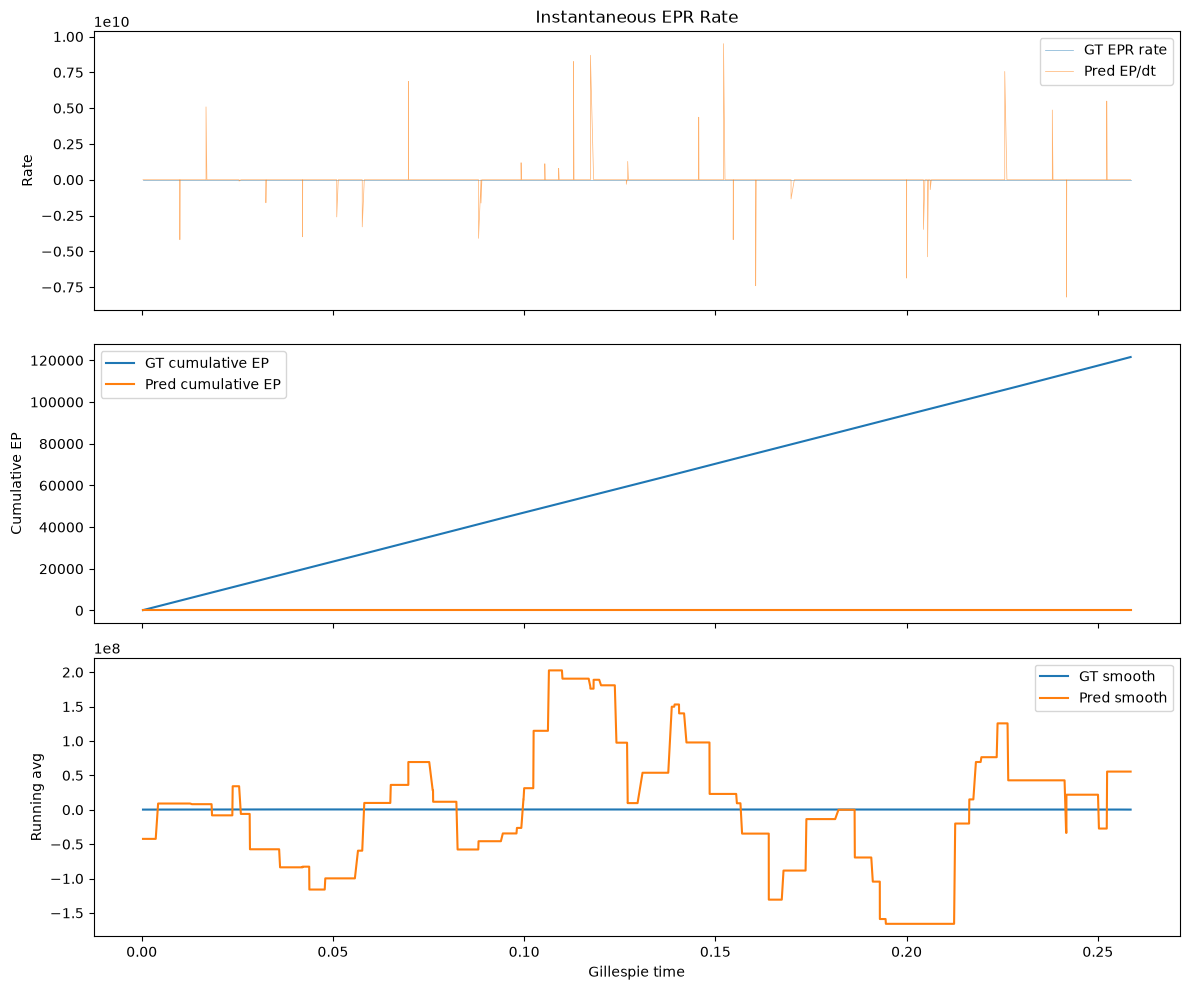

GT mean EPR rate:   4.702152e+05
Pred mean EP/dt:    5.747614e+06
GT mean increment:  1.217090e+02
Pred mean increment:-2.985488e-05


In [31]:
model.eval()
pred_increment = []
pred_rate = []
pred_dt = []

test_sampler = CartesianSeqSampler(
    opt.M_test, opt.L_test, opt.seq_len, opt.video_batch_size, device=opt.device, train=False
)

with torch.no_grad():
    for batch in tqdm(test_sampler):
        b0 = batch[0].to(test_video.device)
        t0 = batch[1][0].to(test_video.device)
        slices = [test_video[(b0, batch[1][i].to(test_video.device))] for i in range(opt.seq_len)]
        x = transform(torch.stack(slices, dim=1).float().to(opt.device))
        J_all = model(x) / opt.scalar
        total_inc = J_all.sum(dim=1) # * (abp_params["L"] ** 2)

        batch_dt = dt_pairs[batch[0].detach().cpu(), batch[1][0].detach().cpu()].numpy()
        inc_np = total_inc.detach().cpu().numpy()
        pred_increment.append(inc_np)
        pred_rate.append(inc_np / batch_dt)
        pred_dt.append(batch_dt)

pred_increment = np.concatenate(pred_increment)
pred_rate = np.concatenate(pred_rate)
pred_dt = np.concatenate(pred_dt)

min_len = min(len(gt_increment_flat), len(pred_increment))
gt_inc = gt_increment_flat[:min_len]
gt_rate = gt_rate_flat[:min_len]
pred_inc = pred_increment[:min_len]
pred_rate_use = pred_rate[:min_len]
plot_time = time_axis[:min_len]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(plot_time, gt_rate, lw=0.5, alpha=0.6, label="GT EPR rate")
axes[0].plot(plot_time, pred_rate_use, lw=0.5, alpha=0.6, label="Pred EP/dt")
axes[0].set_ylabel("Rate")
axes[0].legend()
axes[0].set_title("Instantaneous EPR Rate")

axes[1].plot(plot_time, np.cumsum(gt_inc), label="GT cumulative EP")
axes[1].plot(plot_time, np.cumsum(pred_inc), label="Pred cumulative EP")
axes[1].set_ylabel("Cumulative EP")
axes[1].legend()

window = min(100, max(5, min_len // 10))
kernel = np.ones(window) / window
axes[2].plot(plot_time, np.convolve(gt_rate, kernel, mode="same"), label="GT smooth")
axes[2].plot(plot_time, np.convolve(pred_rate_use, kernel, mode="same"), label="Pred smooth")
axes[2].set_ylabel("Running avg")
axes[2].set_xlabel("Gillespie time")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{current_result_folder}/epr_timeseries.png", dpi=150)
plt.show()

print(f"GT mean EPR rate:   {gt_rate.mean():.6e}")
print(f"Pred mean EP/dt:    {pred_rate_use.mean():.6e}")
print(f"GT mean increment:  {gt_inc.mean():.6e}")
print(f"Pred mean increment:{pred_inc.mean():.6e}")

## 8. Scatter and R2

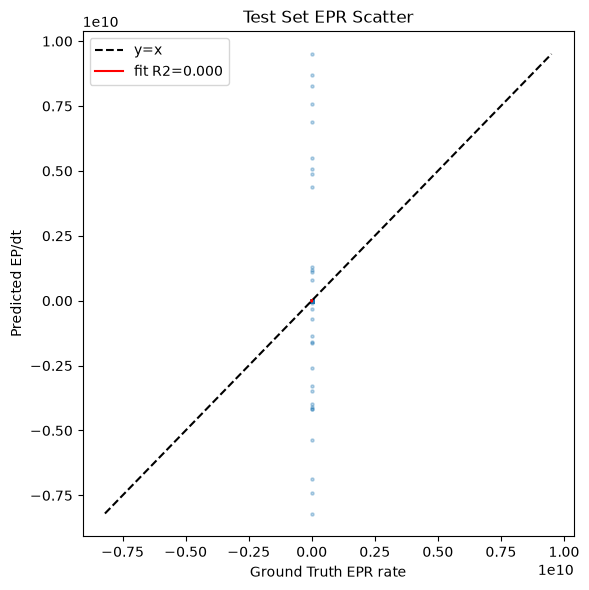

slope=-1485, intercept=7.043e+08, R2=9.578e-05


In [32]:
valid = np.isfinite(gt_rate) & np.isfinite(pred_rate_use)
x_gt = gt_rate[valid]
y_pred = pred_rate_use[valid]

if len(x_gt) >= 2:
    slope, intercept = np.polyfit(x_gt, y_pred, deg=1)
    residual = y_pred - (slope * x_gt + intercept)
    r2 = 1.0 - np.sum(residual**2) / (np.sum((y_pred - y_pred.mean())**2) + 1e-12)
else:
    slope, intercept, r2 = np.nan, np.nan, np.nan

plt.figure(figsize=(6, 6))
plt.scatter(x_gt, y_pred, alpha=0.3, s=5)
lims = [min(x_gt.min(), y_pred.min()), max(x_gt.max(), y_pred.max())]
plt.plot(lims, lims, "k--", label="y=x")
plt.plot(x_gt, slope * x_gt + intercept, "r-", label=f"fit R2={r2:.3f}")
plt.xlabel("Ground Truth EPR rate")
plt.ylabel("Predicted EP/dt")
plt.title("Test Set EPR Scatter")
plt.legend()
plt.tight_layout()
plt.savefig(f"{current_result_folder}/r2_scatter.png", dpi=150)
plt.show()

print(f"slope={slope:.4g}, intercept={intercept:.4g}, R2={r2:.4g}")

## 9. Spatial EP Map

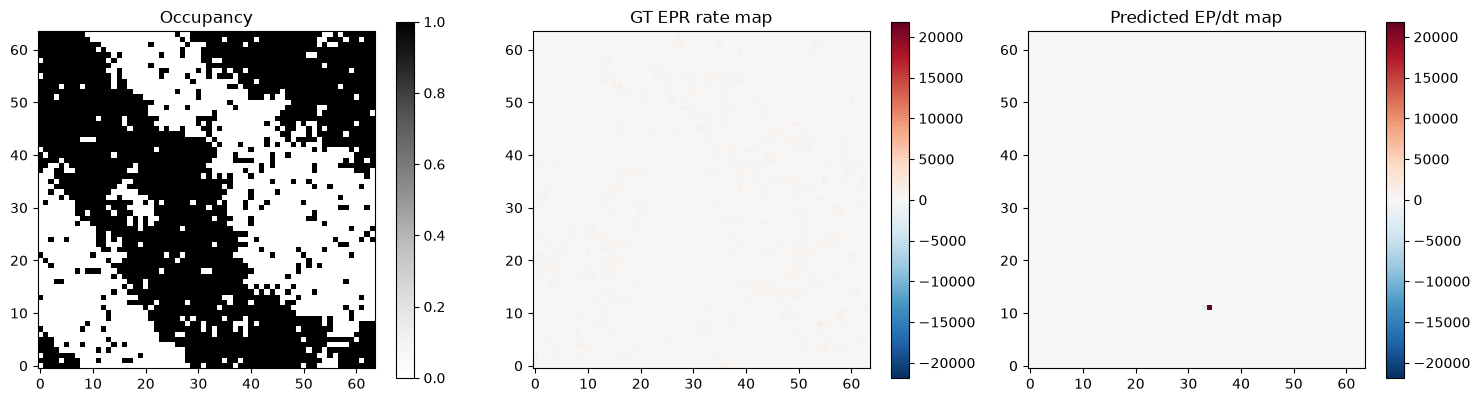

In [33]:
model.eval()
test_sampler_one = CartesianSeqSampler(opt.M_test, opt.L_test, opt.seq_len, 1, device=opt.device, train=False)
ens_idx, traj_idx = next(test_sampler_one)
b0 = ens_idx.to(test_video.device)
slices = [test_video[(b0, traj_idx[i].to(test_video.device))] for i in range(opt.seq_len)]
x = transform(torch.stack(slices, dim=1).float().to(opt.device))
sample_dt = float(dt_pairs[ens_idx.cpu(), traj_idx[0].cpu()].item())

with torch.no_grad():
    maps = model(x, return_maps=True) / opt.scalar

raw_state = test_video[(b0, traj_idx[0].to(test_video.device))][0].detach().cpu().numpy()
occ_t = raw_state
pred_map_k_rate = maps[0].detach().cpu().numpy() / sample_dt
pred_total_map_rate = pred_map_k_rate.sum(axis=0)
gt_map_rate = gt_epr_map_rate

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(occ_t.T, origin="lower", cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("Occupancy")
fig.colorbar(im0, ax=axes[0])

vmax = max(np.abs(gt_map_rate).max(), np.abs(pred_total_map_rate).max(), 1e-12)
im1 = axes[1].imshow(gt_map_rate.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("GT EPR rate map")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(pred_total_map_rate.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("Predicted EP/dt map")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig(f"{current_result_folder}/local_ep_map_2d.png", dpi=150)
plt.show()

## 10. Shell EP Spectrum

2it [00:00, 85.70it/s]


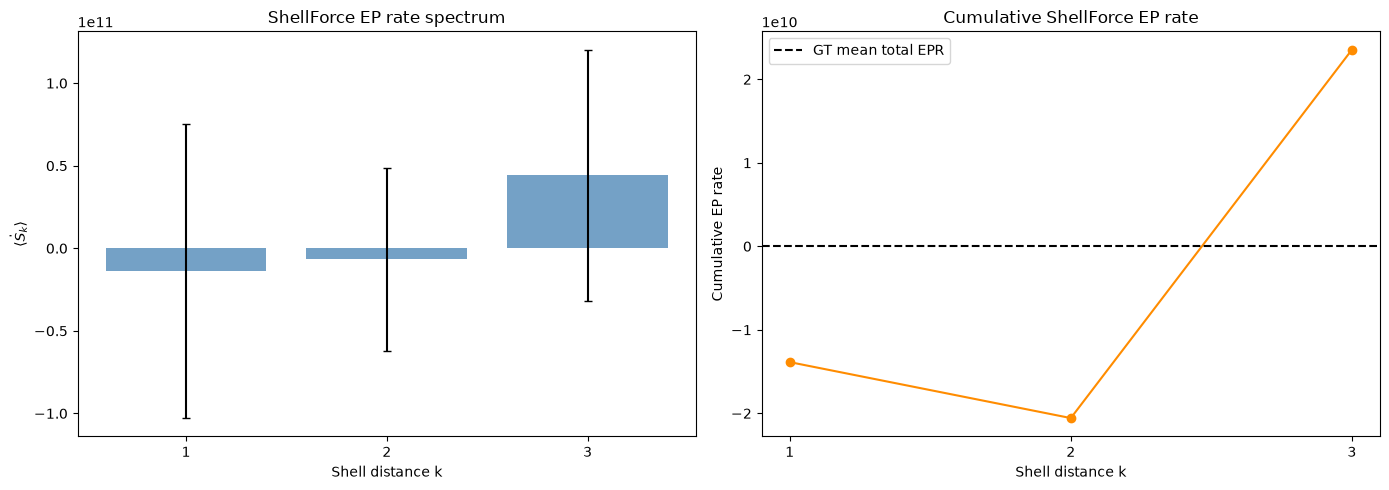

Total predicted EP rate: 2.354224e+10
Total GT EPR rate:       4.702152e+05
  k=1: -1.386994e+10 (-58.9%)
  k=2: -6.703290e+09 (-28.5%)
  k=3: 4.411547e+10 (187.4%)


In [34]:
model.eval()
all_J_rate = []

test_sampler = CartesianSeqSampler(
    opt.M_test, opt.L_test, opt.seq_len, opt.video_batch_size, device=opt.device, train=False
)

with torch.no_grad():
    for batch in tqdm(test_sampler):
        b0 = batch[0].to(test_video.device)
        slices = [test_video[(b0, batch[1][i].to(test_video.device))] for i in range(opt.seq_len)]
        x = transform(torch.stack(slices, dim=1).float().to(opt.device))
        J = model(x) / opt.scalar
        batch_dt = dt_pairs[batch[0].detach().cpu(), batch[1][0].detach().cpu()].numpy()
        J_rate = J.detach().cpu().numpy() * (abp_params["L"] ** 2) / batch_dt[:, None]
        all_J_rate.append(J_rate)

all_J_rate = np.concatenate(all_J_rate, axis=0)
mean_J_rate = all_J_rate.mean(axis=0)
std_J_rate = all_J_rate.std(axis=0)

distances = np.array(list(range(0 if opt.include_k0 else 1, opt.max_distance + 1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(
    distances,
    mean_J_rate,
    yerr=std_J_rate / np.sqrt(len(all_J_rate)),
    capsize=3,
    alpha=0.75,
    color="steelblue",
)
axes[0].set_xlabel("Shell distance k")
axes[0].set_ylabel(r"$\langle \dot{S}_k \rangle$")
axes[0].set_title("ShellForce EP rate spectrum")
axes[0].set_xticks(distances)

axes[1].plot(distances, np.cumsum(mean_J_rate), "o-", color="darkorange")
axes[1].axhline(gt_rate.mean(), color="black", linestyle="--", label="GT mean total EPR")
axes[1].set_xlabel("Shell distance k")
axes[1].set_ylabel("Cumulative EP rate")
axes[1].set_title("Cumulative ShellForce EP rate")
axes[1].set_xticks(distances)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{current_result_folder}/ep_spectrum.png", dpi=150)
plt.show()

print(f"Total predicted EP rate: {mean_J_rate.sum():.6e}")
print(f"Total GT EPR rate:       {gt_rate.mean():.6e}")
for idx, k in enumerate(distances):
    frac = 100.0 * mean_J_rate[idx] / (mean_J_rate.sum() + 1e-12)
    print(f"  k={k}: {mean_J_rate[idx]:.6e} ({frac:.1f}%)")